In [1]:
import os
import argparse
import numpy as np
import pandas as pd
from decimal import *
import matplotlib.pyplot as plt
from tqdm import tqdm

!pip install comet_ml


[notice] A new release of pip is available: 23.0.1 -> 23.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
def update_delta(gamma_j, beta):
    return 1/gamma_j * ((gamma_j*(beta - 1) + 1)**(1/(1 - beta)))

def update_eff(n_a, E_o, S_o, delta_e, k_C, n_d):
    # if E_o - n_a* S_o is positive, the exponential value of this expression will explode in calculation.
    # The original form of efficiency formula contains negative exponent and
    # the simplified form contains the positive exponent
    
    if (E_o - n_a*S_o) >= 0:
        return n_d * (n_a - \
                        ((E_o - n_a*S_o)*n_a*np.exp(-(E_o - n_a * S_o) * k_C * delta_e))/ \
                        (E_o - n_a*S_o*np.exp(-(E_o - n_a*S_o) * k_C * delta_e)))
    else:
        return n_d * (n_a - \
                    ((E_o - n_a*S_o) * n_a)/ \
                        (E_o * np.exp((E_o - n_a * S_o) * k_C * delta_e) - n_a * S_o))
    
def simulate_vals(D_init, E_init, P_init, delta_e, n_d, n_dE, k_C, beta, n_cycle=50):
    S_o, gamma, delta, n_a, eff = [], [], [], [], []
    P_o, E_o, D_e = [P_init], [E_init], [D_init]


    for i in range(n_cycle):
        S_o_j = n_d*D_e[i]
        S_o.append(S_o_j)

        gamma_j = S_o_j/P_o[i]
        gamma.append(gamma_j)

        delta_j = update_delta(gamma_j, beta=beta)
        delta.append(delta_j)

        n_a_j = 1/gamma_j - delta_j
        n_a.append(n_a_j)

        E_o_j = (n_dE**(i+1)) * E_o[0]
        E_o.append(E_o_j)

        eff_j = update_eff(n_a=n_a_j, E_o=E_o_j, S_o=S_o_j, delta_e=delta_e, k_C=k_C, n_d=n_d)
        eff.append(eff_j)
        # print('At cycle {}, PCR efficiency is {}'.format(i, eff_j))

        D_e_j = (eff_j + 1)*D_e[i]
        D_e.append(D_e_j)

        P_o_j = P_o[i] - eff_j * S_o_j
        P_o.append(P_o_j)
    
    return eff, n_a, D_e, S_o, E_o, P_o, gamma, delta

In [4]:
# define constants
k_C = Decimal(15)
n_d = Decimal(1)
n_dE = Decimal(0.99)

beta = Decimal(23)

P_init = Decimal(9.e5)
E_init = Decimal(1e5)
delta_e = Decimal(50)


In [5]:
D_inits = []
D_es = []

for i in tqdm(np.exp(np.linspace(-6, 6, 10000))):
# for i in tqdm(np.linspace(0.000000000000000000000000000000000000000000000000000000000000000001, 100000, 10000)):
    try:
        D_e = simulate_vals(D_init=Decimal(i),#Decimal(i) 
                        E_init=E_init, 
                        P_init=P_init, 
                        delta_e=delta_e,
                        n_d=n_d,
                        n_dE=n_dE,
                        k_C=k_C,
                        beta=beta,
                        n_cycle=49)[2]
    except DivisionByZero:
        print(f'input {i} skipped due to divisionbyzero')

    # plt.plot(D_e, label = 'modelled curve')
    # plt.legend()
    # plt.grid()

    D_inits.append(np.array([i]))
    D_es.append(np.array([float(str(x)) for x in D_e]))
        


curves_dict = {'D Init': D_inits, 'D Values': D_es}
curves_df = pd.DataFrame(curves_dict)
print(curves_df.shape)

100%|██████████| 10000/10000 [01:03<00:00, 158.24it/s]

(10000, 2)


In [6]:
print(curves_df.head())
# curves_df.to_csv('data/curves_vary_D_init_params.csv', index=False)

                    D Init                                           D Values
0  [0.0024787521766663585]  [0.0024787521766663585, 0.00495750427482334, 0...
1  [0.0024817287625312373]  [0.0024817287625312373, 0.00496345744636443, 0...
2   [0.002484708922800808]  [0.002484708922800808, 0.00496941776671445, 0....
3   [0.002487692661767361]  [0.002487692661767361, 0.004975385244457981, 0...
4  [0.0024906799837283397]  [0.0024906799837283397, 0.004981359888189907, ...


In [7]:
import torch
from torch.utils.data import Dataset

class SynthCurveDataset(Dataset):
    def __init__(self, inputs, outputs):
        self.inputs = inputs
        self.outputs = outputs

    def __getitem__(self, index):
        return torch.tensor(self.inputs[index]).unsqueeze(dim=0), torch.tensor(self.outputs[index])
    
    def __len__(self):
        return len(self.inputs)
    


c:\Users\Sased\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
from sklearn.model_selection import train_test_split
from resnet import EKGResNetModel
from base import fit_model
from torch.utils.data import DataLoader

data_train, data_val, labels_train, labels_val = train_test_split(D_es, D_inits, test_size=0.2, random_state=42)
train_dataset = SynthCurveDataset(data_train, labels_train)
val_dataset = SynthCurveDataset(data_val, labels_val)

print(len(train_dataset))
print(len(val_dataset))
print(train_dataset[0])
print(val_dataset[0])


batch_size = 50

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

8000
2000
(tensor([[1.6499e+02, 3.2964e+02, 6.5790e+02, 1.3103e+03, 2.5992e+03, 5.1154e+03,
         9.9208e+03, 1.8750e+04, 3.3997e+04, 5.8160e+04, 9.2795e+04, 1.3777e+05,
         1.9139e+05, 2.5114e+05, 3.1431e+05, 3.7842e+05, 4.4141e+05, 5.0168e+05,
         5.5807e+05, 6.0981e+05, 6.5648e+05, 6.9790e+05, 7.3413e+05, 7.6538e+05,
         7.9198e+05, 8.1432e+05, 8.3284e+05, 8.4799e+05, 8.6023e+05, 8.6999e+05,
         8.7766e+05, 8.8361e+05, 8.8816e+05, 8.9159e+05, 8.9413e+05, 8.9599e+05,
         8.9732e+05, 8.9826e+05, 8.9892e+05, 8.9936e+05, 8.9966e+05, 8.9985e+05,
         8.9997e+05, 9.0005e+05, 9.0010e+05, 9.0013e+05, 9.0014e+05, 9.0015e+05,
         9.0016e+05, 9.0016e+05]], dtype=torch.float64), tensor([164.9942], dtype=torch.float64))
(tensor([[4.4958e+00, 8.9914e+00, 1.7982e+01, 3.5959e+01, 7.1902e+01, 1.4374e+02,
         2.8721e+02, 5.7338e+02, 1.1426e+03, 2.2688e+03, 4.4740e+03, 8.7088e+03,
         1.6562e+04, 3.0321e+04, 5.2537e+04, 8.5038e+04, 1.2804e+05, 1.8012e+05,

In [11]:
NUM_EPOCHS = 50

example_data, example_label = train_dataset[0]

if len(example_data.shape) == 1:
    n_samples = example_data.shape[0]
    n_channels = 1
else:
    n_channels, n_samples = example_data.shape

n_outputs = example_label.shape[0]
regress = [True]*n_outputs

print("cuda available: " + str(torch.cuda.is_available()))


cuda available: False


In [ ]:
model = EKGResNetModel(n_channels=n_channels, n_samples=n_samples, n_outputs=n_outputs, num_rep_blocks=8, kernel_size=16, regress=[True]) #original num_rep_blocks 32
fit_model(model, train_dataloader, val_dataloader, save_path="output/resnet_logsamp_lr2e-2", max_epochs=NUM_EPOCHS, learning_rate=2e-2)


SEQ_LEN:  6 
OUT_FEATURES:  64 

net thinks it will have
  seq_len     : 6
  last active : 384
0.05168972553454222 20393.33984375
2.785151945010404 5838.8779296875
0.009925369080713863 26437.244140625
0.008171680431656631 27233.45703125
11.34120829583629 1681.2559814453125


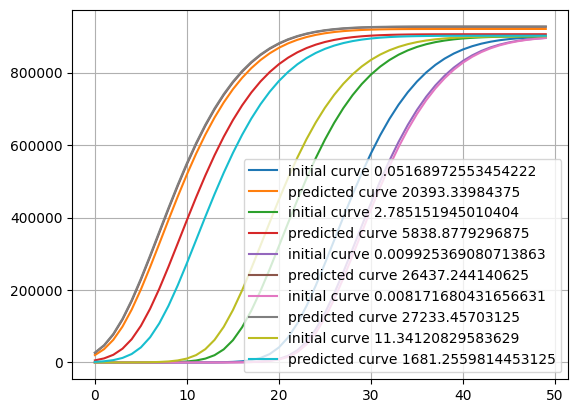

In [12]:
model = EKGResNetModel(n_channels=n_channels, n_samples=n_samples, n_outputs=n_outputs, num_rep_blocks=8, kernel_size=16, regress=[True]) #original num_rep_blocks 32
state_dict = torch.load(f"output/resnet_lr2e-2/model.best.pth.tar")["best_state"]
model.load_state_dict(state_dict)
model.eval()

val_dataloader_iter = iter(val_dataloader)

for i in range(5):
    curve, D_init = next(val_dataloader_iter)
    # print(curve[0].size(), D_init[0].size())

    pred = model(curve.float())
    D_init = D_init[0].data.item()
    pred = pred[0].data.item()
    
    D_e = simulate_vals(D_init=Decimal(D_init),
                        E_init=E_init, 
                        P_init=P_init, 
                        delta_e=delta_e,
                        n_d=n_d,
                        n_dE=n_dE,
                        k_C=k_C,
                        beta=beta,
                        n_cycle=49)[2]
    D_e_pred = simulate_vals(D_init=Decimal(pred),
                        E_init=E_init, 
                        P_init=P_init, 
                        delta_e=delta_e,
                        n_d=n_d,
                        n_dE=n_dE,
                        k_C=k_C,
                        beta=beta,
                        n_cycle=49)[2]
    
    print(D_init, pred)
    plt.plot(D_e, label = f'initial curve {D_init}')
    plt.plot(D_e_pred, label = f'predicted curve {pred}')
    plt.legend()
    plt.grid()
    

torch.Size([1, 1, 50]) torch.Size([1, 1])
10000 9420.666015625


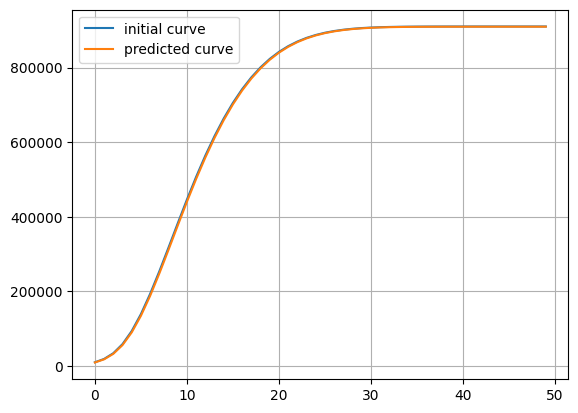

In [13]:
D_init = 10000

D_e = simulate_vals(D_init=Decimal(D_init),
                        E_init=E_init, 
                        P_init=P_init, 
                        delta_e=delta_e,
                        n_d=n_d,
                        n_dE=n_dE,
                        k_C=k_C,
                        beta=beta,
                        n_cycle=49)[2]

curve, D_init = torch.tensor(np.array([[[float(str(x)) for x in D_e]]])), torch.tensor(np.array([[D_init]]))
print(curve.size(), D_init.size())

pred = model(curve.float())
D_init = D_init[0].data.item()
pred = pred[0].data.item()

print(D_init, pred)

D_e_pred = simulate_vals(D_init=Decimal(pred),
                    E_init=E_init, 
                    P_init=P_init, 
                    delta_e=delta_e,
                    n_d=n_d,
                    n_dE=n_dE,
                    k_C=k_C,
                    beta=beta,
                    n_cycle=49)[2]

plt.plot(D_e, label = 'initial curve')
plt.plot(D_e_pred, label = 'predicted curve')
plt.legend()
plt.grid()